# micrograd

Building an Autograd Engine from Scratch

This notebook follows Karpathy's first lecture in the "Neural Networks: Zero to Hero" series. We build a scalar-valued autograd engine from scratch in pure Python — every operation tracks its inputs and knows how to propagate gradients backward through the computation graph. By the end, we'll have a minimal but fully functional neural network trained with gradient descent, all without PyTorch or any other framework.

The key insight: **backpropagation is just the chain rule applied recursively over a directed acyclic graph.** Once you see it from first principles, frameworks like PyTorch go from "magic" to "convenient automation."

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Manual Backpropagation

Before we build the autograd engine, we start with the basics: computing derivatives by hand, numerically approximating gradients with finite differences, and manually tracing gradients through a simple expression. This builds the intuition for what our `Value` class will eventually automate.

We'll work through a single neuron with a `tanh` activation — the smallest meaningful unit of a neural network — and compute every gradient by hand. Only after we've done it manually will we write the code that does it for us.

In [2]:
def f(x):
    return 3*x**2 - 4*x + 5

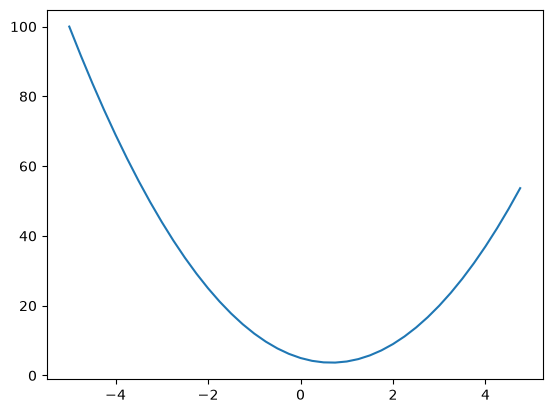

In [3]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)

In [4]:
h = 0.00000001
x = 2/3
(f(x+h) - f(x)) / h

0.0

In [5]:
h = 0.00000001

a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
c += h
d2 = a*b + c
print(f'd1:{d1}\nd2:{d2}\nslop:{(d2-d1) / h}')

d1:4.0
d2:4.000000010000001
slop:1.000000082740371


In [6]:
# The core of our autograd engine: a scalar Value that tracks its computational history.
#
# Every Value node stores:
#   data      — the scalar value
#   grad      — the gradient accumulated during backpropagation
#   _prev     — the set of child nodes (inputs that produced this value)
#   _op       — the operation that created this node (for visualization)
#   _backward — a closure that propagates this node's gradient to its children
#
# _prev is a set (not a tuple) because a computation graph is a DAG, not a tree —
# a single node can be used as input to multiple operations, but it only appears
# once in the set of predecessors. Using a set also prevents duplicate traversal
# during topological sort.
#
# Key design choice: _backward is stored on the OUTPUT node, not the input nodes.
# If we stored it on inputs, reusing a node in multiple operations would overwrite
# its _backward function — only the last operation's gradient rule would survive.

class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda : None
        self._prev = set(_children)
        self._op = _op
        self.label = label
    
    def __repr__(self):
        return f"Value(label={self.label}, data={self.data})"
    
    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        res = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += res.grad
            other.grad += res.grad
        res._backward = _backward

        return res

    def __radd__(self, other):
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        res = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * res.grad
            other.grad += self.data * res.grad
        res._backward = _backward

        return res

    def __rmul__(self, other):
        return self * other

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        # reflected subtraction: called when Python evaluates `other - self`
        # where `other` is not a Value (e.g., `2 - Value(3.0)`).
        # We delegate to `other + (-self)` instead of `self - other` —
        # the latter would flip the sign and compute the wrong result.
        return other + (-self)

    def __neg__(self):
        return self * -1

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        res = Value(self.data**other, (self, ), f'**{other}')
        
        def _backward():
            self.grad += other * self.data**(other-1) * res.grad
        res._backward = _backward

        return res

    def tanh(self):
        # We implement tanh manually (rather than using math.tanh) so we can define
        # a custom backward pass. The derivative of tanh is 1 - tanh²(x),
        # which we compute efficiently by reusing the forward result (res.data).
        res = Value((math.exp(2 * self.data) - 1) / (math.exp(2 * self.data) + 1), (self, ), 'tanh')
        
        def _backward():
            self.grad += (1 - res.data**2) * res.grad
        res._backward = _backward
        
        return res

    def backward(self):
        # Topological sort: collect all nodes reachable from this one,
        # ordered so that every node appears AFTER its children.
        # Then reverse the list and call _backward on each node —
        # this guarantees that a node's gradient is fully accumulated
        # before we propagate it to its inputs.
        
        # Start backpropagation: the gradient of the output with respect to itself is 1.0
        self.grad = 1.0
        topo = []
        visited = set()
        
        def sort_(v):
            visited.add(v)
            for child in v._prev:
                if child not in visited:
                    sort_(child)
            topo.append(v)
        sort_(self)

        # Reverse to get the correct backpropagation order:
        # start from the output (now first) and work backward to the inputs (now last)
        for node in reversed(topo):
            node._backward()

In [7]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a * b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
print(L, L.grad, L._prev, L._op)

Value(label=L, data=-8.0) 0.0 {Value(label=d, data=4.0), Value(label=f, data=-2.0)} *


In [8]:
# Karpathy's graphviz code for visualizing expression DAGs.
# Graphviz isn't commonly used in production ML/DL workflows — we're using it here
# purely for visualization to build intuition about the computation graph.
# I only changed the node string format to f-string.

from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = f"{{ {n.label} | data {n.data:.4f} | {n.grad:.4f} }}", shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

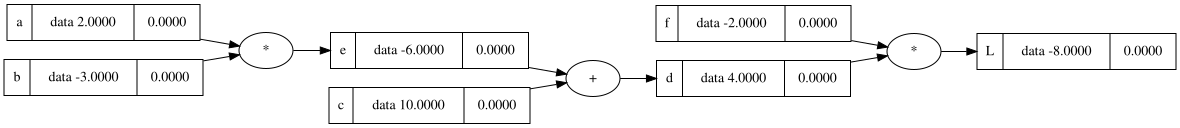

In [9]:
draw_dot(L)

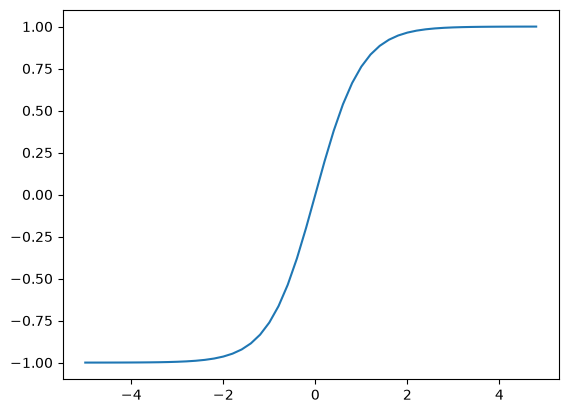

In [10]:
plt.plot(np.arange(-5, 5, 0.2), np.tanh(np.arange(-5, 5, 0.2)))

In [11]:
# neuron init
# inputs
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias
b = Value(6.8813735870195432, label='b')

x1w1 = x1 * w1; x1w1.label = 'x1w1'
x2w2 = x2 * w2; x2w2.label = 'x2w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'
n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh(); o.label = 'o'

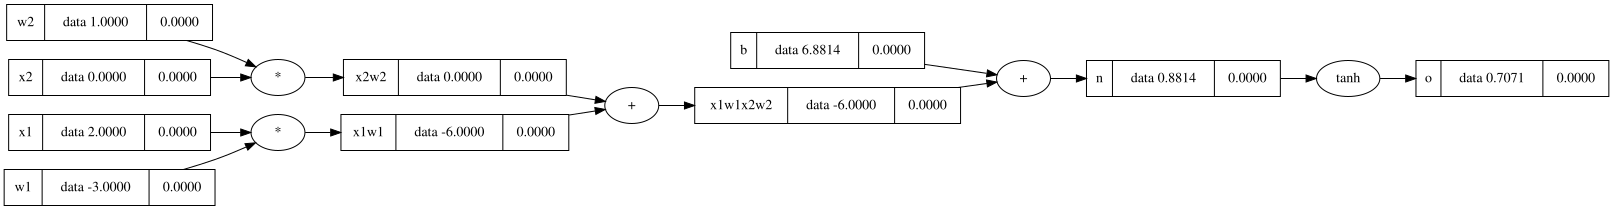

In [12]:
draw_dot(o)

In [13]:
o.backward()

In [14]:
o.grad = 1.0
n.grad = math.exp(2*n.data) * 4 / pow(math.exp(2*n.data) + 1, 2) # do / dn = 1 - o.data**2
b.grad = 0.5
x1w1x2w2.grad = 0.5
x1w1.grad = 0.5
x2w2.grad = 0.5
x1.grad = -1.5
w1.grad = 1
x2.grad = 0.5
w2.grad = 0

In [15]:
def lol():
    h = 0.000001

    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')
    
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')
    
    b = Value(6.8813735870195432, label='b')

    x1w1 = x1 * w1; x1w1.label = 'x1w1'
    x2w2 = x2 * w2; x2w2.label = 'x2w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

    n = x1w1x2w2 + b; n.label = 'n'

    o = n.tanh(); o.label = 'o'
    
    o1 = o

    x1 = Value(2.0, label='x1')
    x2 = Value(0.0, label='x2')
    
    w1 = Value(-3.0, label='w1')
    w2 = Value(1.0, label='w2')
    
    b = Value(6.8813735870195432, label='b')

    x1w1 = x1 * w1; x1w1.label = 'x1w1'
    x2w2 = x2 * w2; x2w2.label = 'x2w2'
    x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1w1x2w2'

    n = x1w1x2w2 + b; n.label = 'n'
    n.data += h

    o = n.tanh(); o.label = 'o'
    o2 = o

    n.grad = (o2.data - o1.data) / h
    print(n.grad)
lol()


0.49999964646385564


## Backpropagation with PyTorch (Autograd)

Now that we've built our own autograd engine, let's verify it against PyTorch. We'll run the exact same neuron forward and backward pass using `torch.Tensor` with `requires_grad=True` and compare the gradients.

The point of this section is to show that PyTorch does exactly what our `Value` class does — it builds a computation graph behind the scenes and runs backpropagation through it. The only difference is that PyTorch's graph is built in C++ (via ATen) and can run on a GPU. The math is identical.

In [16]:
import torch

In [18]:
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o)
print(o.data)
print(o.data.item())

o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

tensor([0.7071], dtype=torch.float64, grad_fn=<TanhBackward0>)
tensor([0.7071], dtype=torch.float64)
0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## Building a Neural Network from Scratch

A single neuron is interesting, but a network of neurons is where things get powerful. In this section we stack our `Value` objects into a proper multi-layer perceptron (MLP): a `Neuron` class that computes `tanh(W·x + b)`, a `Layer` class that groups parallel neurons, and an `MLP` class that stacks layers sequentially.

We then train this network on a tiny binary classification dataset using gradient descent — the same loop we'll use for much larger models later in the course. The scale is small, but the principles are exactly the same.

In [19]:
import random

# Building a simple binary classifier neural network from our Value objects.
#
# We organize the code into three levels of abstraction:
#   Neuron  — a single unit: tanh(W·x + b)
#   Layer   — a group of parallel neurons, all receiving the same inputs
#   MLP     — a stack of layers, feeding the output of one into the next
#
# Convention: __init__ sets up the skeleton (random weights and biases),
# and __call__ feeds inputs through for a forward pass.
#
# In real engineering, the __init__ parameters are typically named `nin`
# (number of inputs) and `nout` (number of outputs). We use more verbose
# names here for clarity while studying.

class Neuron:
    def __init__(self, neuron_in_num: int):
        self.weights = [Value(random.uniform(-1, 1)) for _ in range(neuron_in_num)]
        self.bias = Value(random.uniform(-1, 1))

    def __call__(self, inputs_from_prev_layer_neurons: list):
        # w·x + b, then squash through tanh
        out = sum((w*x for w, x in zip(self.weights, inputs_from_prev_layer_neurons)), start=self.bias)
        squash = out.tanh()
        return squash

    def parameters(self):
        return self.weights + [self.bias]

class Layer:
    def __init__(self, neuron_in_num: int, neuron_out_num: int):
        self.neurons = [Neuron(neuron_in_num) for _ in range(neuron_out_num)]
    
    def __call__(self, inputs_from_prev_layer: list):
        out = [neuron(inputs_from_prev_layer) for neuron in self.neurons]
        return out if len(out) != 1 else out[0]

    def parameters(self):
        return [n for neuron in self.neurons for n in neuron.parameters()]

class MLP:
    def __init__(self, layers_num: list):
        self.layers = [Layer(layers_num[i], layers_num[i+1]) for i in range(len(layers_num) - 1)]
    
    def __call__(self, inputs_from_outer):
        # inputs_from_outer: a list of Values, one per input feature.
        # The first element of layers_num is the number of inputs,
        # and the last element is the number of outputs (usually 1 for binary classification).
        out = inputs_from_outer
        for layer in self.layers:
            out = layer(out)
        return out

    def parameters(self):
        return [l for layer in self.layers for l in layer.parameters()]

In [20]:
x = [Value(2.0, label='x1'), Value(3.0, label='x2'), Value(-1.0, label='x3')]
nn = MLP([3, 4, 4, 1])    # 3 inputs ; 1 output; 2 mediate layers (each has 4 neurons)
# Actually when building nn, 3 layers are built in nn. They are two mediate layers and one output layer
# The input layer is x logically.

nn(x)
# draw_dot(nn(x))

Value(label=, data=0.756448689679913)

In [21]:
# inputs
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
# desired targets/outputs
ys = [1.0, -1.0, -1.0, 1.0]

# predicted outputs
ypreds = [nn(x) for x in xs]
ypreds

[Value(label=, data=0.756448689679913),
 Value(label=, data=-0.51362004819198),
 Value(label=, data=0.5839318872301238),
 Value(label=, data=0.6137097477988316)]

In [22]:
# Compute the loss: Sum of Squared Errors (SSE)
# Each term is (y_true - y_pred)², summed across all 4 training examples.
# Note: we use SSE (sum) rather than MSE (sum / n). The constant factor 1/n
# doesn't change the direction of the gradient — it's absorbed by the learning rate.
err = [(y - ypred)**2 for y, ypred in zip(ys, ypreds)]
loss = sum(err)
print(err)
print(loss)

[Value(label=, data=0.05931724075863133), Value(label=, data=0.23656545752077182), Value(label=, data=2.5088402233843814), Value(label=, data=0.1492201589456423)]
Value(label=, data=2.9539430806094265)


In [23]:
loss.backward()

In [24]:
print(nn.layers[0].neurons[0].weights[0].grad)
print(nn.layers[0].neurons[0].weights[0].data)

0.1460991192696288
-0.6587023551880571


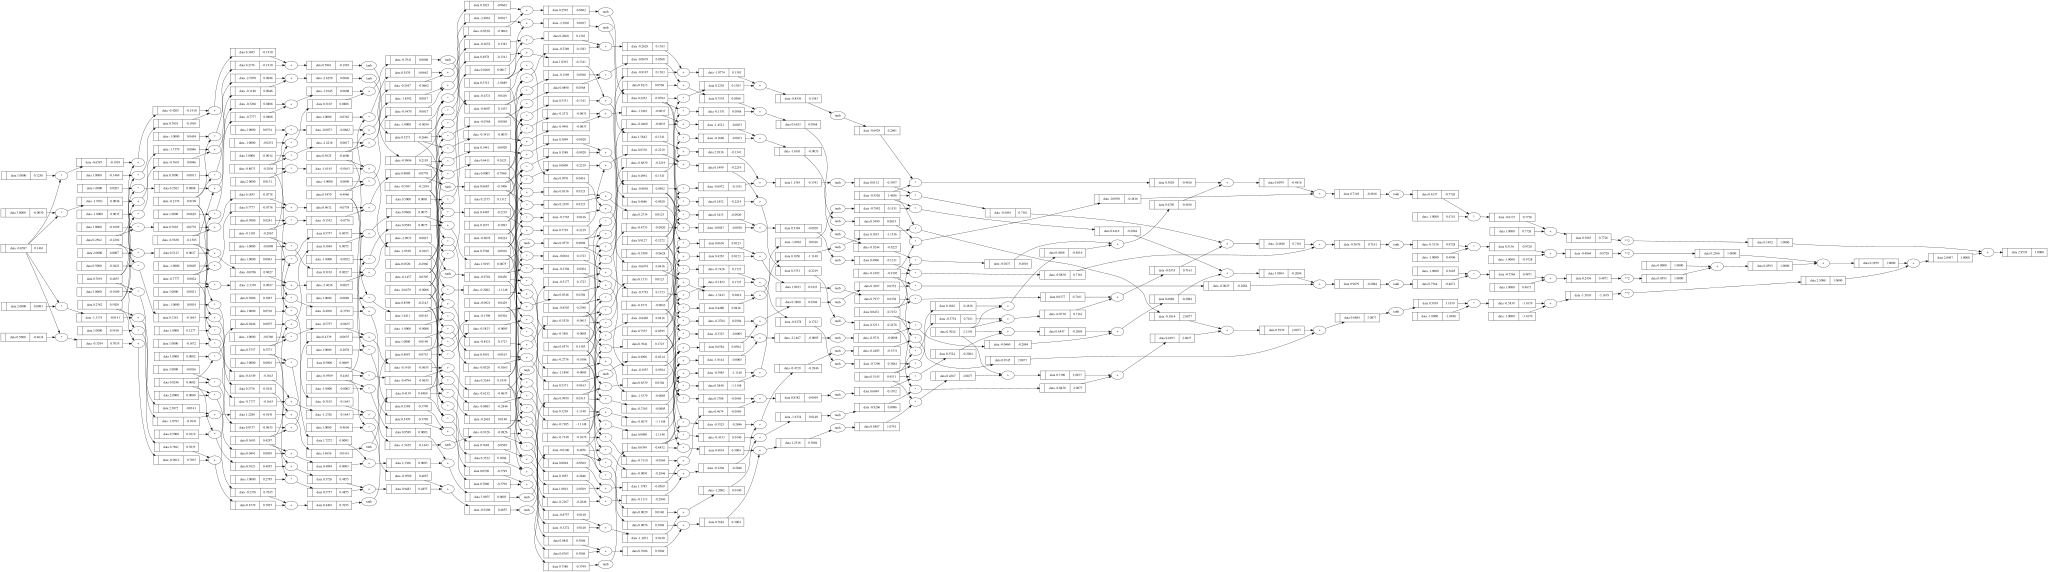

In [25]:
draw_dot(loss)

In [26]:
print(nn.parameters())
print(len(nn.parameters()))

[Value(label=, data=-0.6587023551880571), Value(label=, data=0.769073012574389), Value(label=, data=-0.23762051419344155), Value(label=, data=0.23815744265189087), Value(label=, data=0.2561729010229876), Value(label=, data=-0.7776619371210469), Value(label=, data=-0.31032625765850796), Value(label=, data=-0.582978907020314), Value(label=, data=0.024551155651041157), Value(label=, data=0.5757281037362523), Value(label=, data=-0.958892441646636), Value(label=, data=0.3602797656138401), Value(label=, data=-0.8072604885658046), Value(label=, data=0.5470352364566555), Value(label=, data=0.0520189408374061), Value(label=, data=0.5625491246779892), Value(label=, data=0.8509366250607904), Value(label=, data=-0.0921220773030329), Value(label=, data=-0.7139584530370275), Value(label=, data=0.7554562491010282), Value(label=, data=0.32435097629770593), Value(label=, data=-0.6478633196283845), Value(label=, data=0.35880833090190656), Value(label=, data=-0.27764875896761065), Value(label=, data=-0.6

In [27]:
# 3. Update the weights and biases (gradient descent step)
#
# The fastest way to decrease the loss is to move each parameter in the
# opposite direction of its gradient. The gradient tells us how much the
# loss changes when we nudge that parameter — so we nudge in the negative
# direction, scaled by a learning rate.
#
# Learning rate considerations:
#   - Too small → painfully slow convergence
#   - Too large → may overshoot the minimum, or even increase the loss
#   - Learning rate decay: start large (fast progress), then gradually
#     shrink to fine-tune: `lr = 1.0 - 0.9 * k / 100`
#   - There's no universal "right" learning rate — it depends on the
#     network architecture, the data, and the loss function design.
#     Picking a good one is part art, part experience.
for p in nn.parameters():
    p.data += -0.01 * p.grad

In [28]:
# 1. Forward pass
# Recalculate the predictions and loss after the gradient update.
ypreds = [nn(x) for x in xs]
err = [(y - ypred)**2 for y, ypred in zip(ys, ypreds)]
loss = sum(err)

# After one update step, the loss should decrease noticeably.
# The predictions (ypreds) are getting closer to the targets (ys).
print(ypreds)
print(loss)

[Value(label=, data=0.7466076040974008), Value(label=, data=-0.527234152392561), Value(label=, data=0.5369073029971366), Value(label=, data=0.6016605204383259)]
Value(label=, data=2.808473651948637)


In [29]:
# 2. Backward pass
# Reset all gradients to zero BEFORE calling backward().
# THIS IS CRITICAL: gradients accumulate by default (+=), so if we forget
# to zero them, each backward pass adds to the previous one, corrupting
# the gradient signal. This is the #1 gotcha in training loops.
for p in nn.parameters():
    p.grad = 0.0
loss.backward()

In [30]:
# The training loop: the heart of deep learning.
#
# Every training loop, from this tiny 41-parameter MLP to GPT-4, follows
# the same three steps:
#   1. Forward pass  — compute predictions and loss
#   2. Backward pass — compute gradients via backpropagation
#   3. Update        — nudge parameters in the opposite direction of the gradient
#
# The only thing that changes at scale is the model architecture, the data,
# and the engineering needed to make it all fit in memory.

for k in range(200):

    # forward pass
    ypreds = [nn(x) for x in xs]
    loss = sum([(y - ypred)**2 for y, ypred in zip(ys, ypreds)])

    # backward pass (don't forget to zero gradients first!)
    for p in nn.parameters():
        p.grad = 0.0
    loss.backward()

    # update weights and biases
    for p in nn.parameters():
        p.data += -0.1 * p.grad
    
    print(f"round {k}: loss: {loss.data}")

round 0: loss: 2.808473651948637
round 1: loss: 1.3581401530173502
round 2: loss: 0.5288606950593875
round 3: loss: 0.2825282081964734
round 4: loss: 0.18761018591081777
round 5: loss: 0.1392674892198588
round 6: loss: 0.11015985679977808
round 7: loss: 0.09081201456902518
round 8: loss: 0.07706349419705476
round 9: loss: 0.06681317734110517
round 10: loss: 0.058889364891873526
round 11: loss: 0.052588567986943044
round 12: loss: 0.0474635657982941
round 13: loss: 0.043216798147962567
round 14: loss: 0.03964278188817981
round 15: loss: 0.03659516125994538
round 16: loss: 0.033966933792683535
round 17: loss: 0.031678098172053935
round 18: loss: 0.029667670130414124
round 19: loss: 0.027888367228839715
round 20: loss: 0.026302978168933958
round 21: loss: 0.024881825969314122
round 22: loss: 0.023600959484553884
round 23: loss: 0.022440840817457997
round 24: loss: 0.021385377165743152
round 25: loss: 0.020421196241186178
round 26: loss: 0.019537096759870927
round 27: loss: 0.0187236266431

In [31]:
ypreds

[Value(label=, data=0.9822616277463887),
 Value(label=, data=-0.9808445633123616),
 Value(label=, data=-0.9705640486202586),
 Value(label=, data=0.9769411823460697)]